In [3]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# Fetch UCI Cervical Cancer dataset (id=383)
cervical = fetch_ucirepo(id=383)

X = cervical.data.features
y = cervical.data.targets

# Combine into single df for EDA
df = pd.concat([X, y], axis=1)
print(df.shape)
df.head()

(858, 36)


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0


In [5]:
print("Columns:", df.columns.tolist())
print("\nLast 5 columns:", df.columns[-5:].tolist())
print("\nBiopsy value counts:")
print(df['Biopsy'].value_counts())
print("\nPositive rate:", df['Biopsy'].mean().round(4))

Columns: ['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis', 'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis', 'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']

Last 5 columns: ['Dx', 'Hinselmann', 'Schiller', 'Citology', 'Biopsy']

Biopsy value counts:
Biopsy
0    803
1     55
Name: count, dtype: int64

Positive rate: 0.0641


In [6]:
# Missing value analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df[missing_df['missing_count'] > 0])

                                    missing_count  missing_pct
STDs: Time since first diagnosis              787        91.72
STDs: Time since last diagnosis               787        91.72
IUD                                           117        13.64
IUD (years)                                   117        13.64
Hormonal Contraceptives                       108        12.59
Hormonal Contraceptives (years)               108        12.59
STDs:HPV                                      105        12.24
STDs:AIDS                                     105        12.24
STDs:Hepatitis B                              105        12.24
STDs:HIV                                      105        12.24
STDs                                          105        12.24
STDs:cervical condylomatosis                  105        12.24
STDs:vulvo-perineal condylomatosis            105        12.24
STDs:syphilis                                 105        12.24
STDs:pelvic inflammatory disease              105      

In [7]:
# Drop 91%+ missing columns
df.drop(columns=['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis'], inplace=True)

# Define our 7 CHW production features (what the model actually uses)
CHW_FEATURES = [
    'Age',
    'Num of pregnancies',
    'Smokes',
    'Hormonal Contraceptives',
    'IUD',
    'STDs',
    'Biopsy'  # target
]

# CHW-only dataframe
df_chw = df[CHW_FEATURES].copy()

print("Full df shape:", df.shape)
print("CHW df shape:", df_chw.shape)
print("\nMissing in CHW features:")
print(df_chw.isnull().sum())

Full df shape: (858, 34)
CHW df shape: (858, 7)

Missing in CHW features:
Age                          0
Num of pregnancies          56
Smokes                      13
Hormonal Contraceptives    108
IUD                        117
STDs                       105
Biopsy                       0
dtype: int64


In [8]:
from sklearn.impute import SimpleImputer

# Separate features and target
X_chw = df_chw.drop(columns=['Biopsy'])
y_chw = df_chw['Biopsy']

# Median imputation
imputer = SimpleImputer(strategy='median')
X_chw_imputed = pd.DataFrame(
    imputer.fit_transform(X_chw),
    columns=X_chw.columns
)

print("Missing after imputation:", X_chw_imputed.isnull().sum().sum())
print("\nFeature distributions after imputation:")
print(X_chw_imputed.describe().round(2))

Missing after imputation: 0

Feature distributions after imputation:
          Age  Num of pregnancies  Smokes  Hormonal Contraceptives    IUD  \
count  858.00              858.00  858.00                   858.00  858.0   
mean    26.82                2.26    0.14                     0.69    0.1   
std      8.50                1.40    0.35                     0.46    0.3   
min     13.00                0.00    0.00                     0.00    0.0   
25%     20.00                1.00    0.00                     0.00    0.0   
50%     25.00                2.00    0.00                     1.00    0.0   
75%     32.00                3.00    0.00                     1.00    0.0   
max     84.00               11.00    1.00                     1.00    1.0   

         STDs  
count  858.00  
mean     0.09  
std      0.29  
min      0.00  
25%      0.00  
50%      0.00  
75%      0.00  
max      1.00  


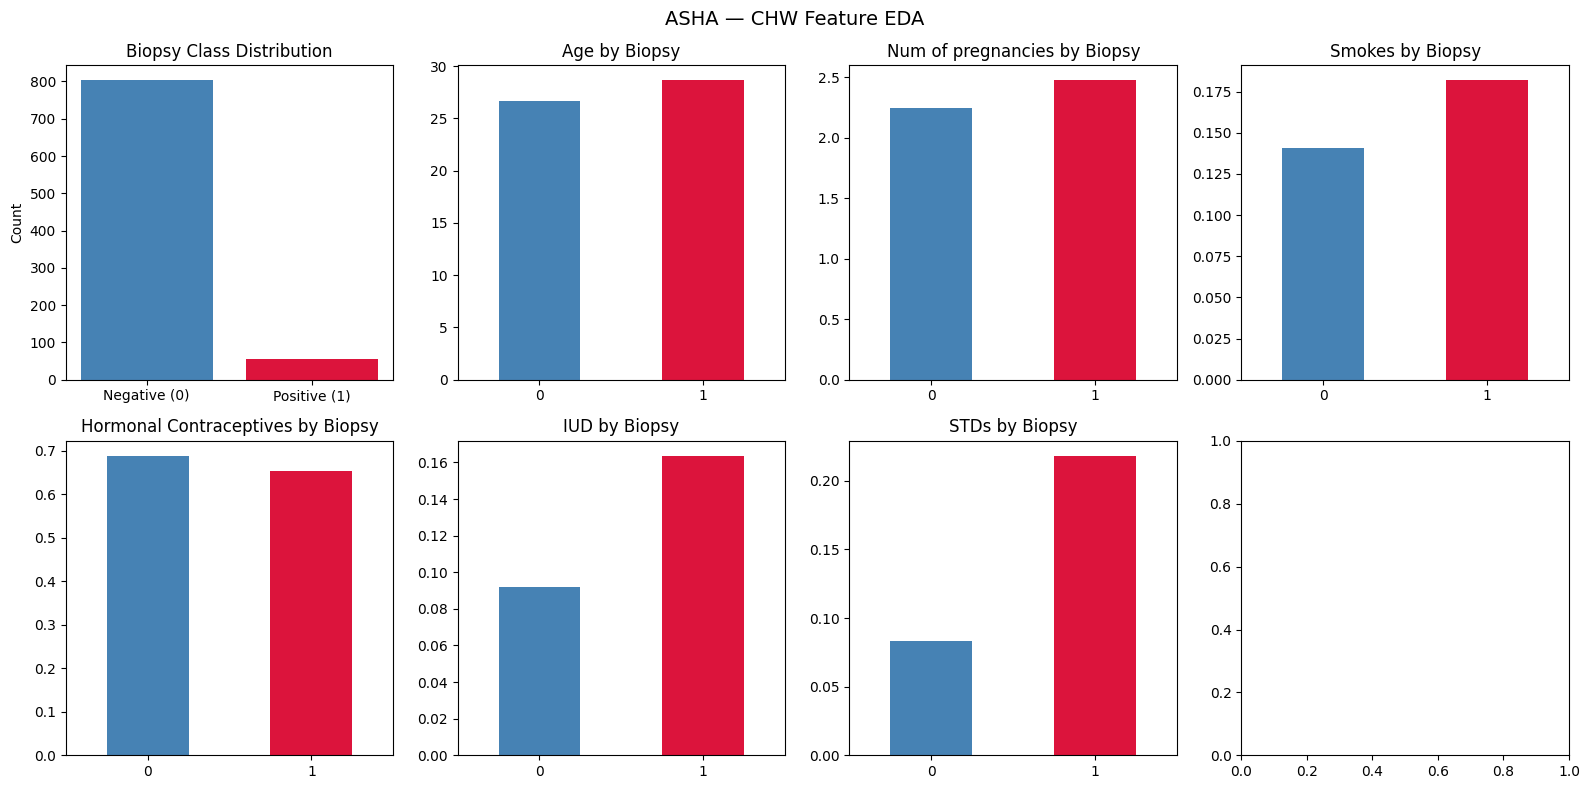

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('ASHA — CHW Feature EDA', fontsize=14)

# Class distribution
axes[0, 0].bar(['Negative (0)', 'Positive (1)'], y_chw.value_counts(), color=['steelblue', 'crimson'])
axes[0, 0].set_title('Biopsy Class Distribution')
axes[0, 0].set_ylabel('Count')

# Feature distributions by Biopsy
features = X_chw_imputed.columns.tolist()
for i, feat in enumerate(features):
    ax = axes[(i+1)//4, (i+1)%4]
    X_chw_imputed.groupby(y_chw)[feat].mean().plot(kind='bar', ax=ax, color=['steelblue','crimson'])
    ax.set_title(f'{feat} by Biopsy')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_chw_features.png', dpi=150)
plt.show()

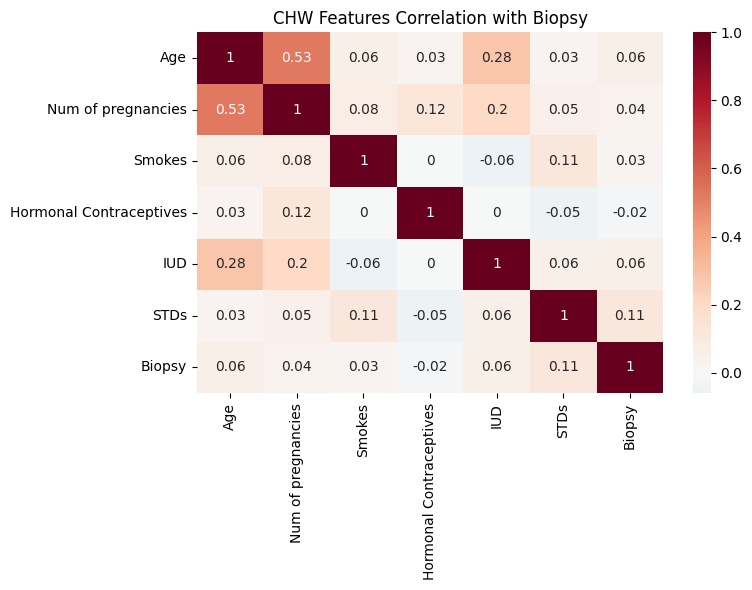

In [14]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr_data = pd.concat([X_chw_imputed, y_chw.reset_index(drop=True)], axis=1)
sns.heatmap(corr_data.corr().round(2), annot=True, cmap='RdBu_r', center=0)
plt.title('CHW Features Correlation with Biopsy')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150)
plt.show()